In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
!which python

/bin/python


In [3]:
import os
import sys
sys.path.insert(0, '/iopsstor/scratch/cscs/xyixuan/benchmark-image-tokenzier')

from Tokenizer.Emu3VisionTokenizer import Emu3VisionTokenizer
from Tiler import Tiler
from utils import load_all_images

/usr/local/lib/python3.12/dist-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
from pathlib import Path
import matplotlib.pyplot as plt
import torch

In [5]:
images, image_names, _ = load_all_images("/iopsstor/scratch/cscs/xyixuan/benchmark-image-tokenzier/assets/original")

Loaded: graph_theory1.png
Loaded: line_chart.png
Loaded: logo1.png
Loaded: logo2.png
Loaded: math_draft1.png
Loaded: menu.jpeg
Loaded: mri_human_brain.png
Loaded: physics1.png
Loaded: physics2.png
Loaded: tcp_1.png


Linear scaling ratio: None/512 = 1.000
Pixel per tile ratio: None²/512² = 1.000
No pixel change: same resolution processing
Original image: 3×2100×1400
Downsampling to: 2100×1400 (ratio: 1.000)
Padding to: 2560×1536
Creating 5×3 = 15 tiles of 512×512
Showing 5×3 = 15 tiles


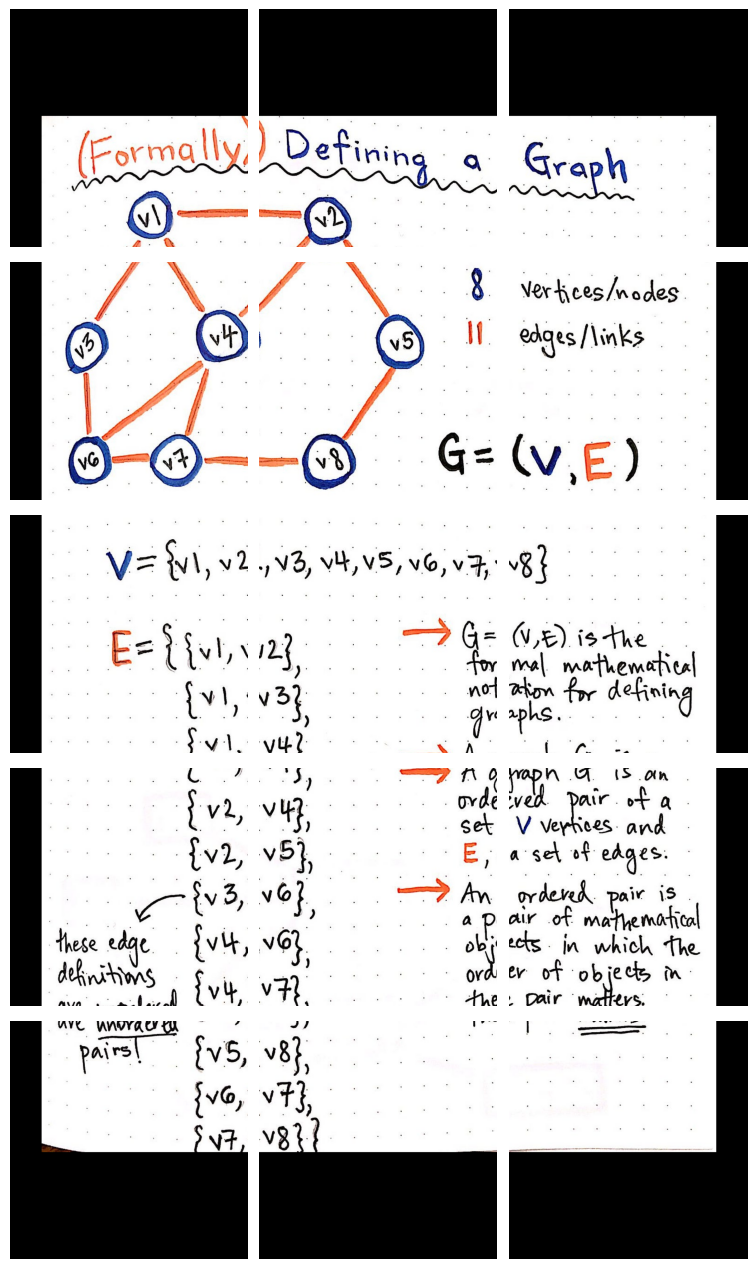

In [21]:
tiler = Tiler(tile_size=512, pad_value=-1.0)

image = images[0]
res = tiler(image)
tiler.show_tiles(res['tiles'], res['metadata'])

In [7]:
tokenizer = Emu3VisionTokenizer()

Loading Emu3VisionTokenizer from BAAI/Emu3-VisionTokenizer...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/file_download.py:943: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


✓ Emu3VisionTokenizer loaded successfully
Emu3VisionTokenizer loaded:
  Total parameters: 270.74M (270,740,287)
  Trainable parameters: 270.74M (270,740,287)


Original image: 3×1248×832
Downsampling to: 1248×832 (ratio: 1.000)
Padding to: 1536×1024
Creating 3×2 = 6 tiles of 512×512


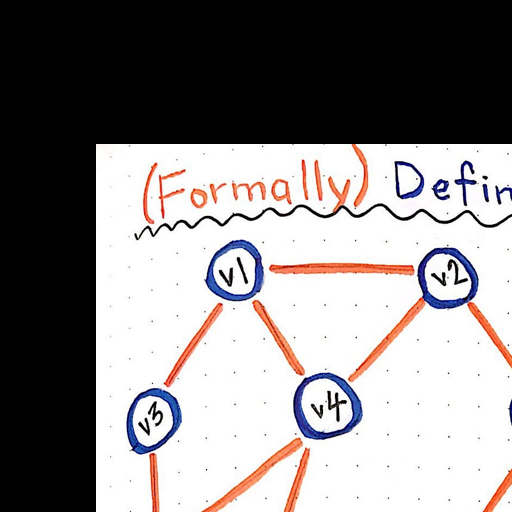

In [8]:
image_tensor = tokenizer.processor(image, return_tensors="pt")["pixel_values"].squeeze(0)
image_tiled = tiler(image_tensor)['tiles'].to('cuda')
first_tile = tokenizer.postprocess(image_tiled[0].unsqueeze(0))
first_tile

In [9]:
with torch.no_grad():
    indices = tokenizer.model.encode(image_tiled[0].unsqueeze(0))

In [10]:
indices.shape

torch.Size([1, 64, 64])

In [11]:
indices

tensor([[[ 4385,  9865,  8628,  ..., 10701,  4455, 13643],
         [ 4221, 13568,  8734,  ...,   211,  2727,   211],
         [ 1895,  2235, 10277,  ...,  7997,   507,  2727],
         ...,
         [13754,     1,  8628,  ...,  5050, 12644, 10533],
         [ 8747,  2235, 10277,  ...,  4054, 10516, 11458],
         [ 7448,  4347,  9441,  ..., 15335,  3150, 12360]]], device='cuda:0')

In [15]:
token_id = 9865
height, width = indices.shape[-2:]   # assuming indices.shape = (B, H, W)
half_height = height // 2

# Clone the first element (shape: H x W)
indices_clone = indices[0].clone()

# Replace top half
indices_clone[:half_height, :] = token_id


In [16]:
indices_clone.unsqueeze(0).shape

torch.Size([1, 64, 64])

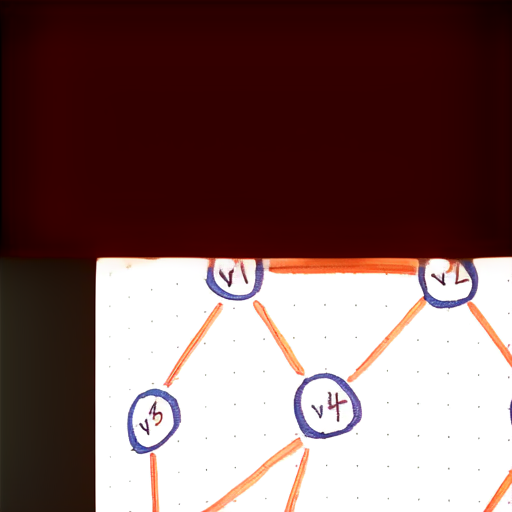

In [17]:
reconstructed = tokenizer.decode(indices_clone.unsqueeze(0))
tokenizer.postprocess(reconstructed)

In [ ]:
import matplotlib.pyplot as plt
import os
import torch

# Initialize the Emu3VisionTokenizer
tokenizer = Emu3VisionTokenizer()

# Initialize tiler
tile_orig_size = 512
tile_resize = 512
tiler = Tiler(tile_size=tile_orig_size, pad_value=-1.0, tile_resize=tile_resize)

device = 'cuda' if torch.cuda.is_available() else 'cpu'

# Setup paths
RECONSTRUCTION_PATH = f'/iopsstor/scratch/cscs/xyixuan/benchmark-image-tokenzier/assets/{tokenizer.name}_{tile_orig_size}-{tile_resize}'
os.makedirs(RECONSTRUCTION_PATH, exist_ok=True)

# Reduce batch size to avoid memory issues
batch_size = 8

print(f"Found {len(images)} images to process")
print(f"Using tiler with tile_size={tiler.tile_size}")
print(f"Processing tiles in batches of {batch_size}")

# Process each image with tiling
with torch.no_grad():
    for idx, (image, name) in enumerate(zip(images, image_names)):
        print(f"\n{'='*60}")
        print(f"Processing image {idx+1}/{len(images)}: {name}")
        print(f"{'='*60}")

        # Use tokenizer's preprocess method but remove batch dimension for tiling
        image_tensor = tokenizer.preprocess(image).squeeze(0)
        print(f"Normalized image shape: {image_tensor.shape}")

        # Tile the normalized image
        print("🔲 Tiling image...")
        result = tiler(image_tensor)
        tiles = result['tiles']  # Shape: (total_tiles, C, tile_h, tile_w)
        metadata = result['metadata']

        print(f"Number of tiles: {tiles.shape[0]}")
        print(f"Tile shape: {tiles.shape[1:]}")

        # Process tiles in batches to avoid OOM
        total_tiles = tiles.shape[0]
        reconstructed_tiles_list = []
        all_indices = []

        print(f"🔄 Processing {total_tiles} tiles in batches of {batch_size}")

        for i in range(0, total_tiles, batch_size):
            end_idx = min(i + batch_size, total_tiles)
            batch_tiles = tiles[i:end_idx].to(device)

            print(f"  📦 Processing batch {i//batch_size + 1}/{(total_tiles + batch_size - 1)//batch_size}: tiles {i+1}-{end_idx}")

            # Process this batch through the tokenizer
            indices, additional_info = tokenizer.encode(batch_tiles)
            reconstructed_batch = tokenizer.decode(indices, additional_info)

            # Clamp and move to CPU to save GPU memory
            reconstructed_batch = reconstructed_batch.clamp(-1, 1).cpu()
            reconstructed_tiles_list.append(reconstructed_batch)
            all_indices.append(indices.cpu())

            # Clear GPU memory
            del batch_tiles, reconstructed_batch, indices
            if torch.cuda.is_available():
                torch.cuda.empty_cache()

        # Concatenate all results
        reconstructed_tiles = torch.cat(reconstructed_tiles_list, dim=0)
        all_indices_tensor = torch.cat(all_indices, dim=0)

        print(f"Encoded codes shape: {all_indices_tensor.shape}")

        # Calculate tokens and compression ratio
        total_tokens = all_indices_tensor.numel()
        original_pixels = image_tensor.shape[-2] * image_tensor.shape[-1]
        compression_ratio = original_pixels / total_tokens

        print(f"Total tokens across all tiles: {total_tokens}")
        print(f"Original image pixels: {original_pixels}")
        print(f"Compression ratio: {compression_ratio:.2f}x")

        # Reconstruct full image from tiles
        reconstructed_full = tiler.full_reconstruct(reconstructed_tiles, metadata)

        print(f"Reconstructed image shape: {reconstructed_full.shape}")

        # Convert to PIL for display and saving using tokenizer's postprocess
        original_pil = tokenizer.postprocess(image_tensor.unsqueeze(0))
        reconstructed_pil = tokenizer.postprocess(reconstructed_full.unsqueeze(0))

        # Create filename with token count
        name_without_ext = os.path.splitext(name)[0]
        output_filename = f"{name_without_ext}_tiled_{total_tokens}.png"
        output_path = os.path.join(RECONSTRUCTION_PATH, output_filename)

        # Save the reconstructed image
        reconstructed_pil.save(output_path)
        print(f"  💾 Saved: {output_filename}")

        # Show results
        fig, axes = plt.subplots(1, 2, figsize=(20, 10))

        # Original image
        axes[0].imshow(original_pil)
        axes[0].set_title(f"Original: {name}")
        axes[0].axis('off')

        # Reconstructed image
        axes[1].imshow(reconstructed_pil)
        axes[1].set_title(f"Reconstructed: {name_without_ext}_tiled_{total_tokens}")
        axes[1].axis('off')

        plt.tight_layout()
        plt.show()

        # Show all tiles in grid format
        print("Displaying all tiles in grid:")
        tiler.show_tiles(tiles.cpu(), metadata)

        # Clean up memory
        del tiles, reconstructed_tiles, all_indices_tensor, image_tensor
        if torch.cuda.is_available():
            torch.cuda.empty_cache()

print("\n✅ Processing complete!")

In [ ]:
import matplotlib.pyplot as plt
import os
import torch
from utils import resize_by_ratio

# Initialize the Emu3VisionTokenizer
tokenizer = Emu3VisionTokenizer()


device = 'cuda' if torch.cuda.is_available() else 'cpu'

processing_ratio = 0.85

# Setup paths with ratio in folder name
RECONSTRUCTION_PATH = f'/iopsstor/scratch/cscs/xyixuan/benchmark-image-tokenzier/assets/{tokenizer.name}_ratio_{processing_ratio**2:.3f}'
os.makedirs(RECONSTRUCTION_PATH, exist_ok=True)


# Process each image with resizing
with torch.no_grad():
    for idx, (image, name) in enumerate(zip(images, image_names)):
        print(f"\n{'='*60}")
        print(f"Processing image {idx+1}/{len(images)}: {name}")
        print(f"{'='*60}")

        # Use tokenizer's preprocess method but remove batch dimension
        image_tensor = tokenizer.preprocess(image).squeeze(0)
        print(f"Normalized image shape: {image_tensor.shape}")
        
        # Store original size for later restoration
        original_size = (image_tensor.shape[1], image_tensor.shape[2])  # (H, W)
        
        # Step 1: Resize by ratio to processing size
        print("📉 Resizing by ratio to processing size...")
        resized_tensor = resize_by_ratio(image_tensor, processing_ratio)
        
        # Step 2: Process through tokenizer (encode + decode)
        print("🔄 Processing through tokenizer...")
        # Add batch dimension for tokenizer
        batch_tensor = resized_tensor.unsqueeze(0).to(device)
        
        # Encode and decode
        indices, additional_info = tokenizer.encode(batch_tensor)
        reconstructed_batch = tokenizer.decode(indices, additional_info)
        
        # Remove batch dimension and move to CPU
        reconstructed_tensor = reconstructed_batch.squeeze(0).clamp(-1, 1).cpu()
        
        print(f"Encoded codes shape: {indices.shape}")
        
        # Calculate tokens and compression ratio
        total_tokens = indices.numel()
        original_pixels = original_size[0] * original_size[1]  # H * W
        compression_ratio = original_pixels / total_tokens
        
        print(f"Total tokens: {total_tokens}")
        print(f"Original image pixels: {original_pixels}")
        print(f"Compression ratio: {compression_ratio:.2f}x")
        
        
        # Convert to PIL for display and saving using tokenizer's postprocess
        original_pil = tokenizer.postprocess(image_tensor.unsqueeze(0))
        reconstructed_pil = tokenizer.postprocess(reconstructed_tensor.unsqueeze(0))
        
        # Create filename with ratio and token count
        name_without_ext = os.path.splitext(name)[0]
        output_filename = f"{name_without_ext}_{total_tokens}.png"
        output_path = os.path.join(RECONSTRUCTION_PATH, output_filename)
        
        # Save the reconstructed image
        reconstructed_pil.save(output_path)
        print(f"  💾 Saved: {output_filename}")
        
        # Show results
        fig, axes = plt.subplots(1, 3, figsize=(30, 10))
        
        # Original image
        axes[0].imshow(original_pil)
        axes[0].set_title(f"Original: {name}\n{original_size[0]}×{original_size[1]}")
        axes[0].axis('off')
        
        # Resized version (for reference)
        resized_pil = tokenizer.postprocess(resized_tensor.unsqueeze(0))
        axes[1].imshow(resized_pil)
        axes[1].set_title(f"Resized (ratio {processing_ratio:.3f})\n{resized_tensor.shape[-2]}×{resized_tensor.shape[-1]}")
        axes[1].axis('off')
        
        # Reconstructed image
        axes[2].imshow(reconstructed_pil)
        axes[2].set_title(f"Reconstructed: {name_without_ext}\n{total_tokens} tokens, {compression_ratio:.2f}x compression")
        axes[2].axis('off')
        
        plt.tight_layout()
        plt.show()
        
        # Clean up memory
        del image_tensor, resized_tensor, batch_tensor, indices, reconstructed_batch, reconstructed_tensor
        if torch.cuda.is_available():
            torch.cuda.empty_cache()

print("\n✅ Processing complete!")